# Data Science/AI Assignment

**Group name:** Send Help

**Student names & numbers:**
* [Xue] - [100193]
* [Shaiza] - [99918]
* [Sas] - [101990]
* [Roos] - [101484]

---

## 1. Setup

**Import libraries**

In [38]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set the display format
pd.set_option('display.float_format', '{:.4f}'.format)

**Load dataset(s)**

In [39]:
# CODE CELL: import the necessary dataset(s) for this iteration
df_observation = pd.read_csv("./data/Dicentrarchus labrax.csv", low_memory=False)
df_habitats = pd.read_csv("./data/habitats_cbs_2022.csv")
df_water = pd.read_csv("./data/haringvliet_salinity_temp_daily_2010_2025.csv")

## 2. Data Understanding
**Data exploration**

In [40]:
# convert salinity
df_water[['salinity_mean']] = df_water[['salinity_mean']] / 1000

In [41]:
df_observation.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Dicentrarchus labrax       str    
dtypes: float64(3), int64(1), str(2)
memory usage: 574.9 MB


In [42]:
df_habitats.info()

<class 'pandas.DataFrame'>
RangeIndex: 2179 entries, 0 to 2178
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   decimalLongitude  2179 non-null   float64
 1   decimalLatitude   2179 non-null   float64
 2   agricultural      2179 non-null   float64
 3   built             2179 non-null   float64
 4   coast             2179 non-null   float64
 5   forest            2179 non-null   float64
 6   other             2179 non-null   float64
 7   sand/heather      2179 non-null   float64
 8   water             2179 non-null   float64
 9   wetland           2179 non-null   float64
 10  main_habitat      2179 non-null   str    
dtypes: float64(10), str(1)
memory usage: 187.4 KB


In [43]:
df_water.info()

<class 'pandas.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              5844 non-null   str    
 1   salinity_mean     4667 non-null   float64
 2   temperature_mean  5308 non-null   float64
dtypes: float64(2), str(1)
memory usage: 137.1 KB


In [44]:
df_observation.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,12558786.0000,12558786.0000,12558785.0000,12558786.0000
mean,52.2299,5.5329,8.1428,0.0897
std,0.6647,0.8780,62.6530,2.5155
min,3.5000,3.3500,0.0000,0.0000
25%,51.7000,4.9000,0.0000,0.0000
50%,52.2000,5.6500,1.0000,0.0000
75%,52.8000,6.2000,6.0000,0.0000
max,53.5000,53.4000,100040.0000,1011.0000


In [45]:
df_habitats.describe()

,decimalLongitude,decimalLatitude,agricultural,built,coast,forest,other,sand/heather,water,wetland
count,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000
mean,5.5106,52.2423,9.5712,2.6007,1.5103,1.8161,1.7169,0.4050,1.4614,0.4145
std,0.8900,0.6648,5.3030,3.0534,4.4434,3.0408,2.3667,2.2456,3.4029,2.0897
min,3.3500,50.7500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,4.8500,51.7000,5.3942,0.7801,0.0000,0.1532,0.7353,0.0000,0.1028,0.0000
50%,5.6500,52.2000,10.6239,1.5843,0.0000,0.7351,1.2135,0.0000,0.3183,0.0193
75%,6.1500,52.8000,13.8830,3.3914,0.0000,2.1239,2.0425,0.0270,1.0962,0.1578
max,7.2000,53.5000,29.5228,29.8350,28.9820,28.0752,29.9060,29.4085,29.8636,28.8475


In [46]:
df_water.describe()

,salinity_mean,temperature_mean
count,4667.0000,5308.0000
mean,30.6062,12.4467
std,1.7164,5.0749
min,11.6860,2.8965
25%,29.7366,7.6607
50%,30.7831,12.0286
75%,31.7217,17.3096
max,35.3351,22.2420


In [47]:
print(df_water['salinity_mean'].describe())

count   4667.0000
mean      30.6062
std        1.7164
min       11.6860
25%       29.7366
50%       30.7831
75%       31.7217
max       35.3351
Name: salinity_mean, dtype: float64


---

## 3. Data Preparation

**Merge**


In [48]:
# Convert the 'eventDate' column in the observation dataset to datetime format
df_observation['eventDate'] = pd.to_datetime(df_observation['eventDate'])

# Merge the observation and habitat datasets on the latitude and longitude columns
df_obs_habitat = pd.merge(
    df_observation, 
    df_habitats, 
    on=['decimalLatitude', 'decimalLongitude'], 
    how='left'
)

# Convert the 'eventDate' column in the merged dataset to datetime format and the 'date' column in the water dataset to datetime format
df_obs_habitat['eventDate'] = pd.to_datetime(df_obs_habitat['eventDate'])

# Convert the 'date' column in the water dataset to datetime format and remove timezone information
df_water['date'] = pd.to_datetime(df_water['date']).dt.tz_localize(None)

# Merge the observation-habitat dataset with the water dataset on the 'eventDate' and 'date' columns
df_obs_habitat_water = df_obs_habitat.merge(
    df_water,
    left_on='eventDate',
    right_on='date',
    how='left'
)

# Drop the 'date' column from the merged dataset
df_obs_habitat_water.drop(columns=['date'], inplace=True)

# Convert the 'Dicentrarchus labrax' column to numeric
df_obs_habitat_water['Dicentrarchus labrax'] = pd.to_numeric(df_obs_habitat_water['Dicentrarchus labrax'], errors='coerce')
df_obs_habitat_water.sample(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,salinity_mean,temperature_mean
11127346,53.1000,7.0500,2011-01-06,0.0000,0,0.0000,13.3413,2.6282,0.0000,0.4151,1.2610,0.0000,0.4230,0.5592,agricultural,30.1057,4.2587
5471214,52.0500,6.6500,2013-05-15,0.0000,0,0.0000,13.7446,1.6331,0.0000,1.2949,0.8911,0.0525,0.0733,0.1218,agricultural,30.9584,10.7118
4948540,52.0000,4.8000,2022-05-14,7.0000,0,0.0000,16.1281,1.3873,0.0000,0.0649,0.6672,0.0000,0.7626,0.0807,agricultural,30.8847,13.6169
7797760,52.4500,5.9000,2015-02-08,0.0000,0,0.0000,16.2481,1.7062,0.0000,0.0462,0.7223,0.0000,0.1050,0.0715,agricultural,30.0660,5.6007
7179811,52.3500,5.5500,2019-04-03,9.0000,0,0.0000,9.9720,0.2772,0.0000,0.6821,0.6904,0.0000,6.2700,1.0537,agricultural,30.9301,8.3194


**Cleaning**

In [49]:
# 1. Inspect missing values 
df_missing_obs_habitat = df_obs_habitat[df_obs_habitat.isnull().any(axis=1)]
df_missing_obs_habitat.sample(5)

df_missing = df_obs_habitat_water[df_obs_habitat_water.isnull().any(axis=1)]
df_missing.sample(5)

print(f"Missing value counts: {df_obs_habitat_water.isnull().sum().sum()}")

Missing value counts: 3681572


In [50]:
# 2. Drop rows where habitat info is missing (geographic join failure)
habitat_cols = ['agricultural', 'built', 'coast', 'forest', 'other',
                'sand/heather', 'water', 'wetland', 'main_habitat']

df_no_missing = df_obs_habitat_water.dropna(subset=habitat_cols)


# 3. Sort by date before interpolation
df_no_missing = df_no_missing.copy()
df_no_missing = df_no_missing.sort_values('eventDate').reset_index(drop=True)

# 4. Short gaps (≤14 days): linear interpolation
df_no_missing['salinity_mean'] = (
    df_no_missing['salinity_mean']
    .interpolate(method='linear', limit=14)
)
df_no_missing['temperature_mean'] = (
    df_no_missing['temperature_mean']
    .interpolate(method='linear', limit=14)
)

# 5. Longer gaps (>14 days): fill with historical seasonal mean
df_no_missing['doy'] = pd.to_datetime(df_no_missing['eventDate']).dt.dayofyear
seasonal_sal  = df_no_missing.groupby('doy')['salinity_mean'].transform('mean')
seasonal_temp = df_no_missing.groupby('doy')['temperature_mean'].transform('mean')

df_no_missing['salinity_mean']    = df_no_missing['salinity_mean'].fillna(seasonal_sal)
df_no_missing['temperature_mean'] = df_no_missing['temperature_mean'].fillna(seasonal_temp)

df_no_missing = df_no_missing.drop(columns='doy')

# 6. Verify 
print(f"Remaining missing values after processing: {df_no_missing.isnull().sum()}")

Remaining missing values after processing: decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Dicentrarchus labrax         0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
salinity_mean                0
temperature_mean             0
dtype: int64


In [51]:
# observations with effort but no fish
true_absent = df_no_missing[(df_no_missing['total_observations'] > 0) & (df_no_missing['Dicentrarchus labrax'] == 0)]
print(f"Number of true absent records: {len(true_absent)}")

# no observations at all
no_effort = df_no_missing[df_no_missing['total_observations'] == 0]
print(f"Number of no effort records: {len(no_effort)}")

# clean no effort records
df_clean = df_no_missing[df_no_missing['total_observations'] > 0]

Number of true absent records: 6537558
Number of no effort records: 6019157


**Visualization**

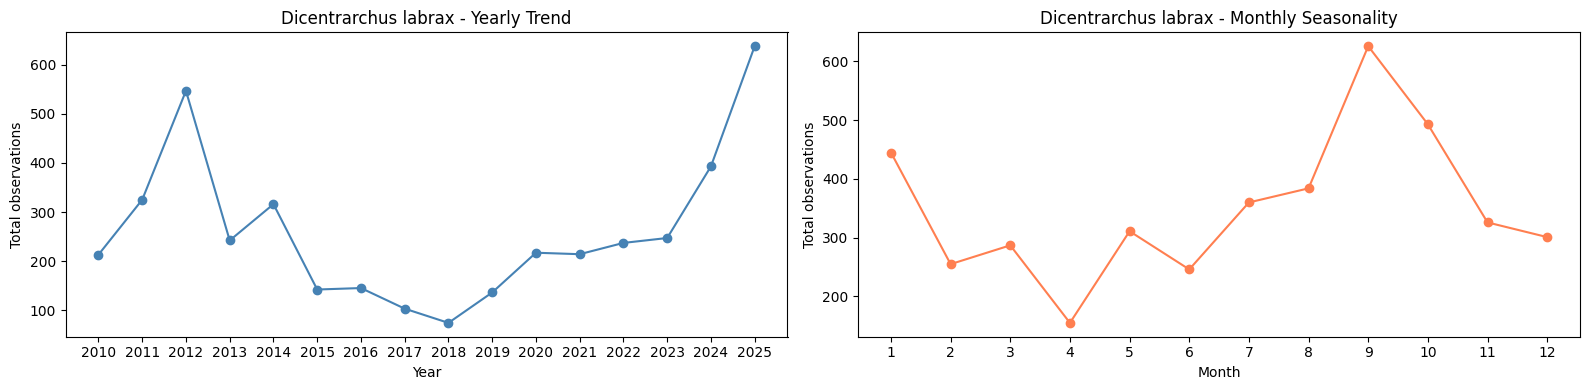

In [52]:
df_visual = df_clean.copy()  

# extract year and month from eventDate for visualization
df_visual['year'] = df_visual['eventDate'].dt.year
df_visual['month'] = df_visual['eventDate'].dt.month

present_mask = df_visual['Dicentrarchus labrax'] > 0
absent_mask  = df_visual['Dicentrarchus labrax'] == 0

#Year
yearly_species = (
    df_visual.groupby('year')['Dicentrarchus labrax']
    .sum()
    .sort_index()
)

# Month seasonality 
monthly_species = (
    df_visual.groupby('month')['Dicentrarchus labrax']
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# left
yearly_species.plot(
    ax=axes[0],
    marker='o',
    color='steelblue'
)

axes[0].set_title('Dicentrarchus labrax - Yearly Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total observations')

# display all years on x-axis with rotation
axes[0].set_xticks(yearly_species.index)

# right
monthly_species.plot(
    ax=axes[1],
    marker='o',
    color='coral'
)

axes[1].set_title('Dicentrarchus labrax - Monthly Seasonality')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total observations')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

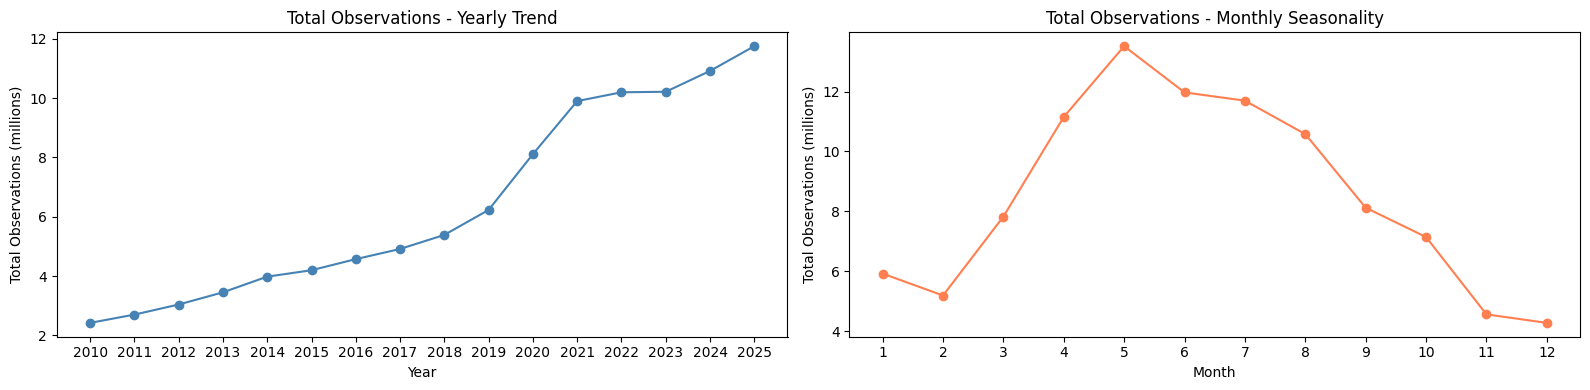

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

#  Yearly 
yearly_total_observations = (
    df_visual.groupby('year')['total_observations']
    .sum()
    .sort_index()
)

(yearly_total_observations / 1e6).plot(
    ax=axes[0],
    marker='o',
    color='steelblue'
)

axes[0].set_title('Total Observations - Yearly Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Observations (millions)')
axes[0].set_xticks(yearly_total_observations.index)


# Monthly 
monthly_total_observations = (
    df_visual.groupby(df_visual['eventDate'].dt.month)['total_observations']
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

(monthly_total_observations / 1e6).plot(
    ax=axes[1],
    marker='o',
    color='coral'
)

axes[1].set_title('Total Observations - Monthly Seasonality')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Observations (millions)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

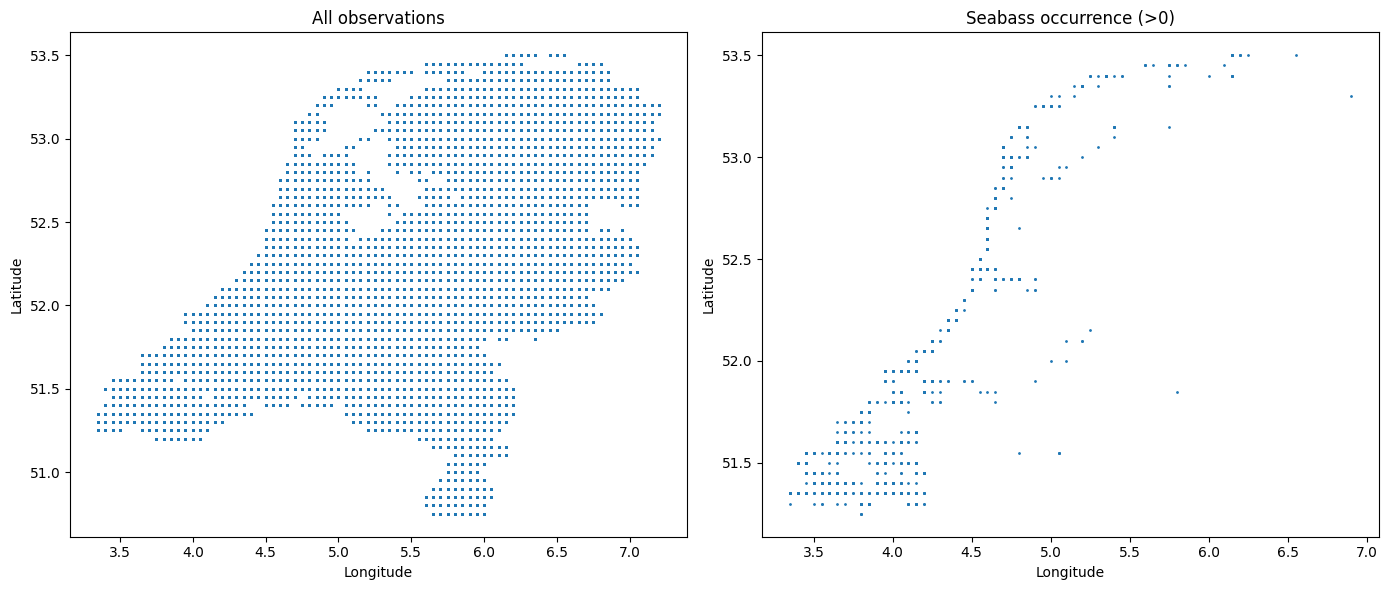

In [54]:
# Display the distribution of all observations and seabass occurrences
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left
axes[0].scatter(
    df_visual['decimalLongitude'],
    df_visual['decimalLatitude'],
    s=1
)
axes[0].set_title("All observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# right
df_seabass = df_visual[present_mask]

axes[1].scatter(
    df_seabass['decimalLongitude'],
    df_seabass['decimalLatitude'],
    s=1
)
axes[1].set_title("Seabass occurrence (>0)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

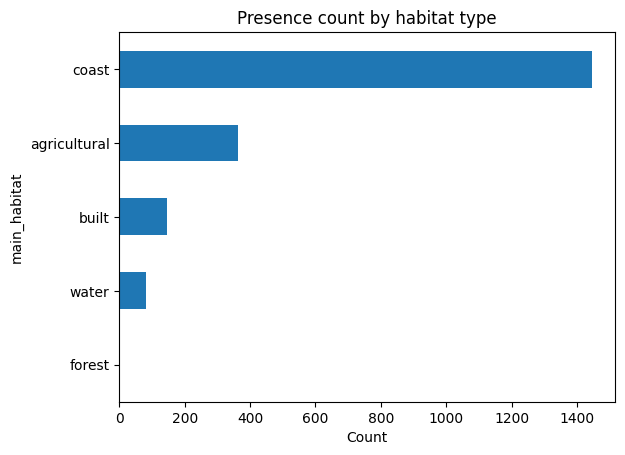

In [55]:
# Display the presence count by habitat type
df_visual[present_mask].groupby('main_habitat')['Dicentrarchus labrax'].count().sort_values().plot(kind='barh')
plt.xlabel('Count')
plt.title('Presence count by habitat type')
plt.show()

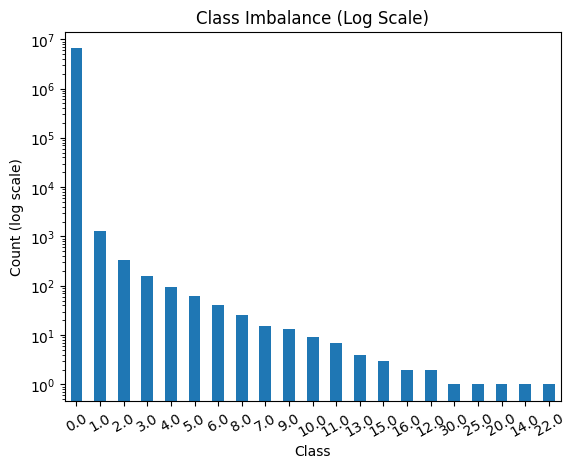

In [56]:
counts = df_clean['Dicentrarchus labrax'].value_counts()

plt.figure()
counts.plot(kind='bar')

plt.yscale('log')

plt.title("Class Imbalance (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=30)

plt.show()

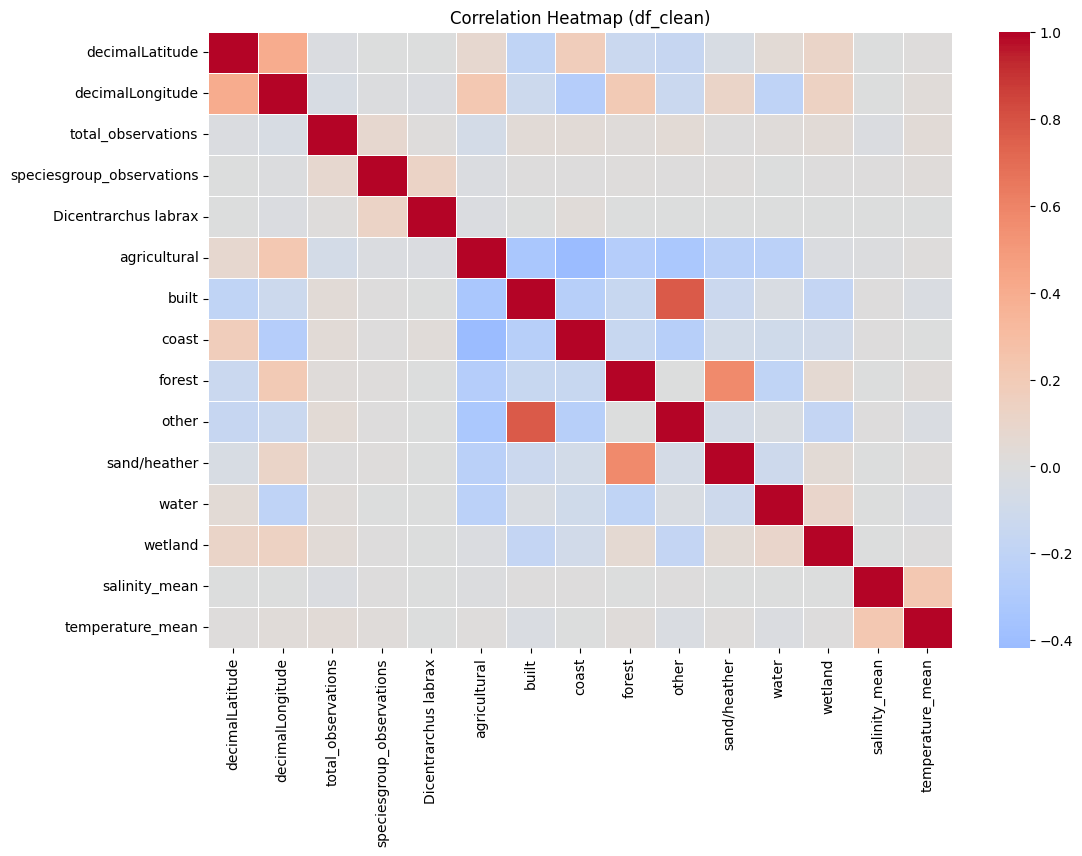

In [57]:
# Display the correlation heatmap for numeric columns in df_clean
df_num = df_clean.select_dtypes(include=['number'])

corr = df_num.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap (df_clean)")
plt.show()

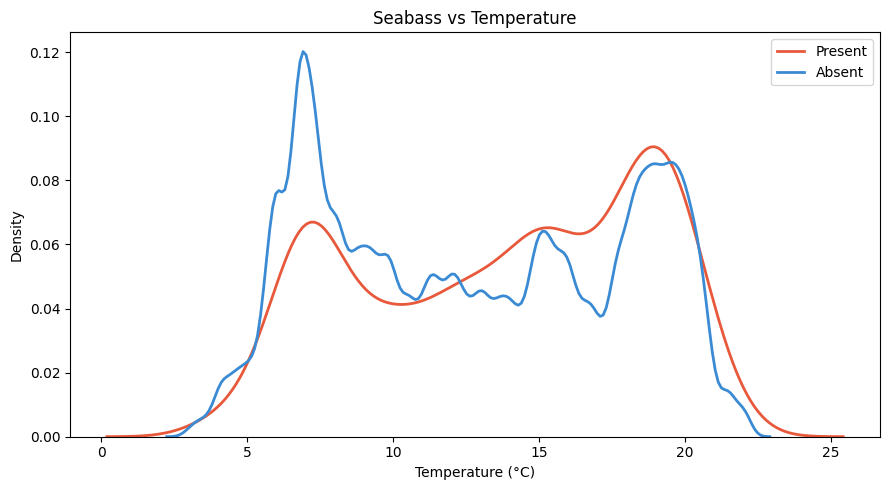

In [58]:
present = df_visual[present_mask]['temperature_mean'].dropna()
absent  = df_visual[absent_mask]['temperature_mean'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(present, ax=ax, color='#E8593C', linewidth=2, label='Present')
sns.kdeplot(absent,  ax=ax, color='#3B8BD4', linewidth=2, label='Absent')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Seabass vs Temperature')
ax.legend()

plt.tight_layout()
plt.show()

**Feature Engineering & Target Definition**

In [59]:
df_ml = df_clean.copy()
df_ml['presence'] = (df_ml['Dicentrarchus labrax'] > 0).astype(int)

print(f"Class distribution:{df_ml['presence'].value_counts()}")

df_ml['year'] = df_ml['eventDate'].dt.year
df_ml['month'] = df_ml['eventDate'].dt.month
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month'] / 12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month'] / 12)

# Feature selection for machine learning
features = [
    'decimalLatitude', 'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'year',
    'month_sin', 'month_cos',
    'agricultural', 'built', 'coast', 'forest',
    'other', 'sand/heather', 'water', 'wetland',
    'salinity_mean', 'temperature_mean',
]


X = df_ml[features]
y = df_ml['presence']

Class distribution:presence
0    6537558
1       2041
Name: count, dtype: int64


In [60]:
# Split the dataset into training and testing sets based on the year
train_df = df_ml[df_ml['year'] < 2024]
test_df  = df_ml[df_ml['year'] >= 2024]

X_train = train_df[features]
y_train = train_df['presence']
X_test  = test_df[features]
y_test  = test_df['presence']

print(f"Train: {len(X_train)} rows, {y_train.sum()} positive")
print(f"Test:  {len(X_test)} rows, {y_test.sum()} positive")

Train: 5414345 rows, 1592 positive
Test:  1125254 rows, 449 positive


## 4. Modeling

Three modelling iterations are performed:
- **Iteration 1** – Baseline Random Forest with default 0.5 threshold
- **Iteration 2** – Same RF, threshold optimised to maximise F1 on the test set
- **Iteration 3** – XGBoost with scale_pos_weight, threshold chosen to keep recall ≥ 0.3

Before training these models, a DummyClassifier is used as a baseline. The DummyClassifier always predicts the majority class, making it possible to check whether the machine learning models perform better than a simple rule-based approach.

**Dummy Baseline** – Majority-class classifier 

In [61]:
# Always predicting the majority class is the simplest possible strategy.
# Any real model should clearly outperform it.
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"{'Dummy Baseline (most_frequent)':-^60}")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

---------------Dummy Baseline (most_frequent)---------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1124805
           1       0.00      0.00      0.00       449

    accuracy                           1.00   1125254
   macro avg       0.50      0.50      0.50   1125254
weighted avg       1.00      1.00      1.00   1125254



**Iteration 1** – Baseline Random Forest (default threshold = 0.5)

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f"{'Random Forest Report':-^50}")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob)}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob)}")

---------------Random Forest Report---------------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1124805
           1       0.02      0.68      0.04       449

    accuracy                           0.99   1125254
   macro avg       0.51      0.83      0.52   1125254
weighted avg       1.00      0.99      0.99   1125254

ROC-AUC: 0.9773017206674646
PR-AUC:  0.32433642065483453


**Iteration 2** - Random forest model with threshold tuning

Best threshold: 0.9713445700373132


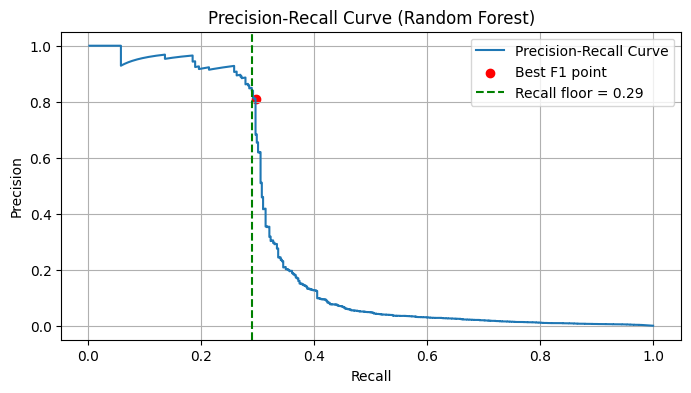

In [63]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob)

precision_adj = precision_curve[:-1]
recall_adj = recall_curve[:-1]

f1_scores = 2 * precision_adj * recall_adj / (precision_adj + recall_adj + 1e-9)

# Best threshold index
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold}")

# Plot PR curve
plt.figure(figsize=(8, 4))
plt.plot(recall_adj, precision_adj, label="Precision-Recall Curve")

# highlight best point
plt.scatter(
    recall_adj[best_idx],
    precision_adj[best_idx],
    color='red',
    label='Best F1 point'
)
plt.axvline(0.29, color='green', linestyle='--', label='Recall floor = 0.29')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print(f"{'Random Forest Report (Tuned)':-^60}")
print(classification_report(y_test, y_pred_tuned))

----------------Random Forest Report (Tuned)----------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1124805
           1       0.81      0.30      0.43       449

    accuracy                           1.00   1125254
   macro avg       0.91      0.65      0.72   1125254
weighted avg       1.00      1.00      1.00   1125254



**Iteration 3** - XGBoost  model with threshold selection

In [65]:
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale, 
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb)}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_xgb)}")

ROC-AUC: 0.9755696995893047
PR-AUC:  0.35312117726194925


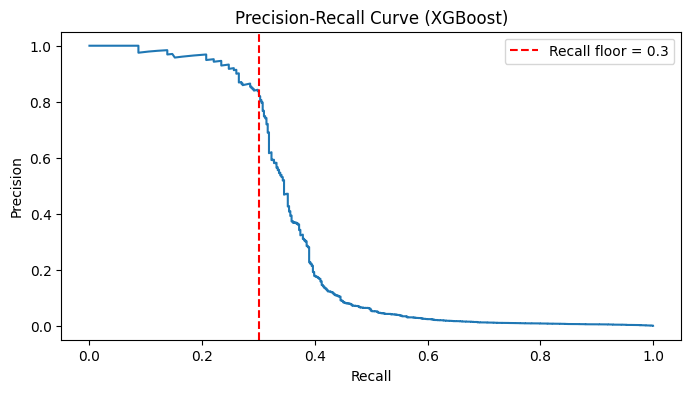

In [66]:
# Finding the best threshold for XGBoost
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)

precision_xgb_a = precision_xgb[:-1]
recall_xgb_a = recall_xgb[:-1]

plt.figure(figsize=(8, 4))
plt.plot(recall_xgb, precision_xgb)
plt.axvline(0.3, color='red', linestyle='--', label='Recall floor = 0.3')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (XGBoost)')
plt.legend()
plt.show()

In [67]:
mask = recall_xgb_a >= 0.3
best_idx = np.argmax(precision_xgb_a[mask])
threshold_xgb = thresholds_xgb[mask][best_idx]

y_pred_xgb = (y_prob_xgb >= threshold_xgb).astype(int)

print(f"{'XGBoost Report':-^60}")
print(classification_report(y_test, y_pred_xgb))

-----------------------XGBoost Report-----------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1124805
           1       0.84      0.30      0.44       449

    accuracy                           1.00   1125254
   macro avg       0.92      0.65      0.72   1125254
weighted avg       1.00      1.00      1.00   1125254



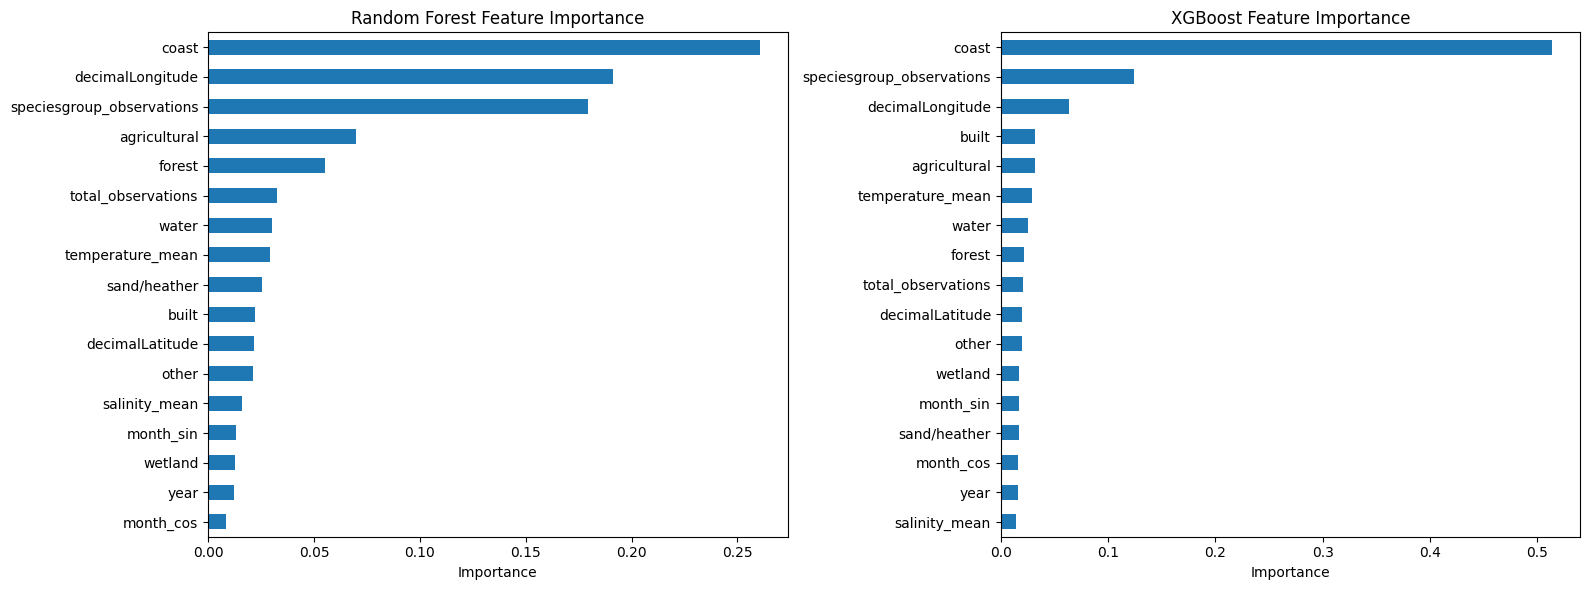

In [68]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp.plot(kind='barh', ax=axes[0])
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

feat_imp_xgb.plot(kind='barh', ax=axes[1])
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()